# REPORT — Predicting NBA Contract Value

A final synthesis of the `nba-contracts` pipeline: baseline, regularized-linear,
tree-ensemble, ceiling-aware (Tobit), and quantile-regression models of
`log_aav_cap_share` (AAV as a share of the signing-season cap, logged), plus a
detailed error analysis. Every number in this notebook is read from the artifacts
written by `PREP.ipynb` and `MODEL_01..04`; nothing is re-fit here.

## 0. Executive summary

**What we built.** A leakage-controlled pipeline that predicts NBA contract value
(`log_aav_cap_share`) from prior-season production, physicals, deal terms, and
team/market context. Everything is fit on train years only (≤2021, n=783); `val`
(2022-23, n=216) is the headline split; `test` (2024-25, n=181) is reported once
and never tuned on. Hyperparameters are chosen by expanding-window walk-forward CV
inside the train window, and every candidate stat is screened through a
deterministic two-layer selection (redundancy → weak correlation) recorded in `linear_features.json`.

**Headline results.**

- **Best model:** walk-forward-tuned **Random Forest** (`rf_tuned`) — val log-RMSE
  **0.399** (R² = 0.849), test **0.424** (R² = 0.811). Ensembles beat the tuned
  linear model and every baseline on val and test.
- **Chosen interpretable model:** `linear_interpretable` (ElasticNet on 35
  controls + 24 chosen stats) — val log-RMSE **0.470** (R² 0.791). Notably the
  all-stats variant ties it (val 0.4701 vs 0.4697), so the interpretable model
  gives up nothing on accuracy — there is no price for interpretability here.
- **Position specialization does not matter for pay.** Hypothesis-driven
  interactions (assists×PG, scoring×SG, blocks×C, rebounds×C) contribute ~0
  (val-RMSE delta ≈ 0); raw box-score stats are noise. Pay follows total on-court
  value, which PER/BPM/VORP/WS already capture.
- **Big markets do not pay more** once player/team quality is controlled. The
  ElasticNet shrinks all five market-size features to exactly 0 (L1 penalty);
  OLS/Tobit coefficients are individually non-zero (|coef| up to 0.11)
  but unstable due to multicollinearity among the five correlated market
  features. The tree partial-dependence is flat.
- **Good teams pay a little less — a real but modest discount.** Holding player
  quality constant, `team_nrtg` (signing team's prior-season quality) carries a
  negative coefficient: ≈ −0.07 in the chosen ElasticNet, −0.12 to −0.13 under
  OLS/Tobit. It is bigger for stars (`team_nrtg × star` ≈ −0.03) and
  identical for re-signings vs movers — a general "good team pays less" effect,
  not a special premium for switching teams.
- **Uncertainty is calibrated, with an honest cost.** Quantile-regression
  [q10, q90] intervals hit 82.9% coverage on val (naive gb-residual interval:
  81.9%) but are ~65% wider — the correct price for a skewed, cap-bound top of the
  market. Coverage falls to 75.1% on test.
- **The cap ceiling is thin and the Tobit fits it.** 6/1,180 deals sit
  exactly at their tier; a relative 3% band admits 22 deals (15 train, 4 val,
  3 test) — all legitimate max-contract stars. A two-stage Heckman selection
  correction was **declined**: the Probit is near-separated (15 censored rows
  vs 59+1 regressors), the Hessian does not invert, and the inverse-Mills
  ratio is NaN — so no ρσ / p-value is reported (see §4).
- **Where the models are wrong (Section 5):** errors concentrate at the very top
  of the market (ceiling-bound stars, systematically under-paid by the model) and
  on one-off veteran deals; errors are roughly normal on the bulk of the data.

**Bottom line.** For transparency, deploy `linear_interpretable`; for raw
accuracy, `rf_tuned`. Either way the market-clearing lessons are robust: pay
tracks total production, not skill mix or market size — and good teams pay
a little less.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from metrics import rmse, mae, r2

PROJECT_ROOT = Path("..")
DM = PROJECT_ROOT / "data" / "model"
TARGET = "log_aav_cap_share"
CEILING_TOL = 0.03

res = pd.read_csv(DM / "results.csv")
prep = pd.read_csv(DM / "prep.csv")
interval = json.load(open(DM / "interval_metrics.json"))
ceiling = json.load(open(DM / "ceiling_metrics.json"))
contender = json.load(open(DM / "contender_metrics.json"))
feat_meta = json.load(open(DM / "linear_features.json"))
pens = pd.read_csv(DM / "predictions_ensemble.csv")
plin = pd.read_csv(DM / "predictions_linear.csv")
pqu = pd.read_csv(DM / "predictions_quantile.csv")

for df, name in ((pens, "ensemble"), (plin, "linear"), (pqu, "quantile")):
    assert (prep["player_id"] == df["player_id"]).all(), f"{name} rows misaligned"

y = prep[TARGET].to_numpy()
masks = {s: prep["split"].eq(s).to_numpy() for s in ("train", "val", "test")}

prep["aav"] = np.exp(prep[TARGET])
gap = prep["max_tier_aav_pct"] - prep["aav"]
prep["gap_rel"] = gap / prep["max_tier_aav_pct"]
prep["at_ceiling"] = prep["gap_rel"].between(0, CEILING_TOL).to_numpy()

print("generated:", pd.Timestamp.now().date())
print("prep rows:", len(prep), "| models in results.csv:", len(res["model"].unique()))
print("canonical features:", len(feat_meta["controls"]), "controls +",
      len(feat_meta["chosen_stats"]), "chosen stats")

generated: 2026-09-03
prep rows: 1364 | models in results.csv: 13
canonical features: 36 controls + 24 chosen stats


## 1. Problem, data & protocol

**Task.** Predict the average annual value of an NBA contract as a share of the
signing-season salary cap, logged (`log_aav_cap_share`). Cap-share makes deals
comparable across CBA regimes; the log keeps error symmetric across role-player
and star contracts.

**Data.** 1,180 modeled deals (of 1,214 in `data/model/features.csv`;
34 removed: 1 duplicate + 3 matched offer-sheet proposals + 30 CBA-slotted
rookie max extensions, documented in PREP cells 2-5), 2015-2025.
Features are documented in `data/model/features.md` and split into:

- **Controls** (always in): deal terms, mechanism, free-agency status, CBA
  regime, physicals, market, and player **position** (structural).
- **Candidate stats** (two-layer selection): prior-season player stats + team
  context.

**Leakage controls.** Player stats are *prior-season*; team context is signing
season but never future; no val/test row influences any fit; hyperparameters are
tuned by walk-forward CV on train years only (eval years 2017-2021), mirroring a
real deployment.

In [2]:
print("split sizes and target:")
ov = pd.DataFrame({
    "n": prep.groupby("split").size(),
    "mean log_aav_cap_share": prep.groupby("split")[TARGET].mean().round(3),
    "median AAV cap-share": prep.groupby("split")["aav"].median().round(4),
})
print(ov.to_string())
print("\ndeal years covered:", prep["deal_year"].min(), "-", prep["deal_year"].max())

pos_cols = [c for c in prep if c.startswith("pos_")]
pos_series = pd.Series(
    prep[pos_cols].idxmax(axis=1).map({c: c[4:].upper() for c in pos_cols}),
    index=prep.index).where(prep[pos_cols].any(axis=1), "n/a")
print("\nposition mix:")
print(pos_series.value_counts().to_string())

print("\nmarket-size mix (team_market_size_ord, 0 = smallest):")
print(prep["team_market_size_ord"].astype(int).value_counts().sort_index().to_string())

split sizes and target:
         n  mean log_aav_cap_share  median AAV cap-share
split                                                   
test   242                  -2.837                0.0580
train  906                  -2.969                0.0541
val    216                  -2.922                0.0544

deal years covered: 2013 - 2026

position mix:
NA    263
SG    242
C     236
PF    219
PG    209
SF    195

market-size mix (team_market_size_ord, 0 = smallest):
team_market_size_ord
0    439
1    260
2    665


## 2. Model comparison

Four families share one registry (`data/model/results.csv`):

1. **Baselines** — global median; segment medians by experience / prior minutes.
2. **Linear (ElasticNet, standardized)** — controls-only, the chosen
   interpretable set, the all-stats ceiling, and the position-interaction
   experiment.
3. **Ensembles** — Random Forest and Gradient Boosting, default and
   walk-forward-tuned, on the canonical set.
4. **Ceiling-aware & quantile** — Tobit MLE and quantile
   regression (τ = 0.50 point model). A two-stage Heckman selection correction
   was declined — near-separated Probit, non-invertible Hessian (see §4).

`val` is the headline split; `test` is held out and shown for context. The
exp-scale RMSE column is on `exp(y) = aav_cap_share` (a fraction, e.g. 0.30 =
30% of the cap; ≈ $1.3-1.4M per cap-share point at a $140M cap).

In [3]:
pd.set_option("display.width", 220)
order = ["global_median", "segment_median_years_pro", "segment_median_prior_mpg",
         "linear_controls_only", "linear_interpretable", "linear_all_stats",
         "linear_posinter", "rf_default", "gb_default", "rf_tuned", "gb_tuned",
         "quantile_median", "tobit_ceiling"]
for split in ("train", "val", "test"):
    t = res[res["split"] == split].set_index("model").reindex(order)
    print(f"===== {split} =====")
    print(t[["rmse", "mae", "r2", "rmse_dollars", "mae_dollars"]].round(3).to_string())

===== train =====
                           rmse    mae     r2  rmse_dollars  mae_dollars
model                                                                   
global_median             1.153  1.007 -0.002         0.105        0.071
segment_median_years_pro  0.876  0.694  0.421         0.088        0.057
segment_median_prior_mpg  0.892  0.738  0.400         0.068        0.048
linear_controls_only      0.621  0.516  0.709         0.062        0.039
linear_interpretable      0.510  0.414  0.804         0.055        0.031
linear_all_stats          0.516  0.418  0.800         0.056        0.032
linear_posinter           0.510  0.413  0.804         0.055        0.031
rf_default                0.160  0.115  0.981         0.016        0.009
gb_default                0.294  0.216  0.935         0.024        0.016
rf_tuned                  0.201  0.142  0.970         0.018        0.011
gb_tuned                  0.336  0.247  0.915         0.028        0.018
quantile_median           0.534  

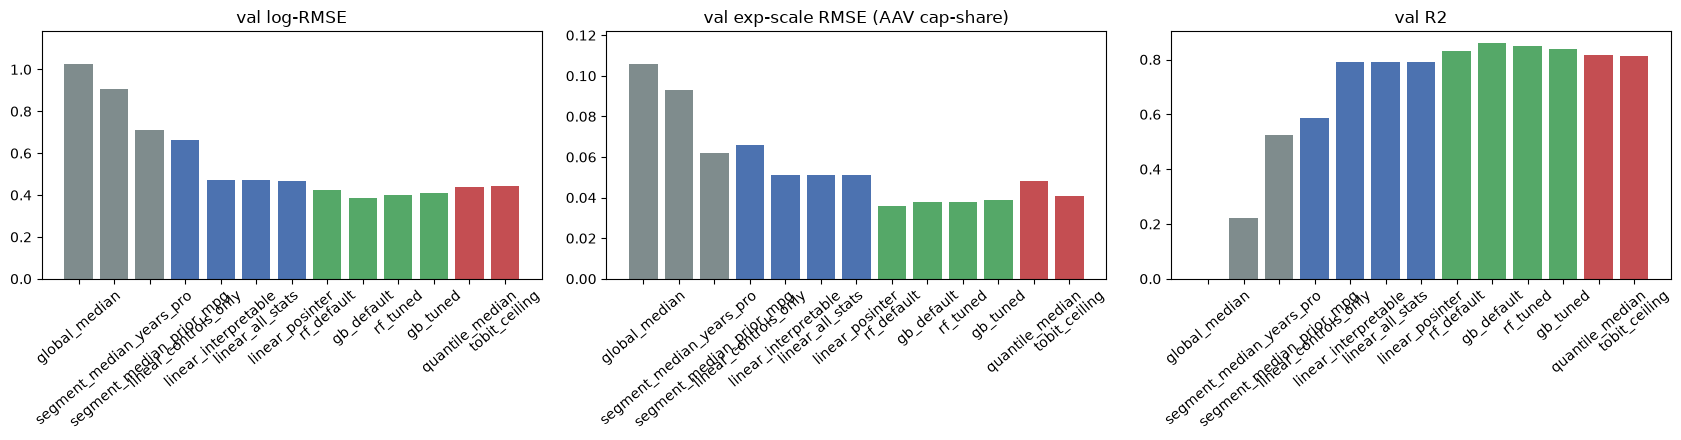

In [4]:
def family(m):
    if m in ("global_median", "segment_median_years_pro", "segment_median_prior_mpg"):
        return "baseline"
    if m.startswith("linear"):
        return "linear"
    if m.startswith(("rf", "gb")):
        return "ensemble"
    return "ceiling/quantile"

FAM_COL = {"baseline": "#7f8c8d", "linear": "#4C72B0",
           "ensemble": "#55A868", "ceiling/quantile": "#C44E52"}
v = res[res["split"] == "val"].set_index("model")
order = ["global_median", "segment_median_years_pro", "segment_median_prior_mpg",
         "linear_controls_only", "linear_interpretable", "linear_all_stats",
         "linear_posinter", "rf_default", "gb_default", "rf_tuned", "gb_tuned",
         "quantile_median", "tobit_ceiling"]
order = [m for m in order if m in v.index]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col, title in ((axes[0], "rmse", "val log-RMSE"),
                       (axes[1], "rmse_dollars", "val exp-scale RMSE (AAV cap-share)"),
                       (axes[2], "r2", "val R2")):
    vv = v.loc[order, col]
    ax.bar(vv.index, vv.values, color=[FAM_COL[family(m)] for m in vv.index])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=40)
    if col != "r2":
        ax.set_ylim(0, vv.max() * 1.15)
fig.tight_layout()
plt.show()

### Interpretability cost and the position experiment

The chosen set (35 controls + 24 chosen stats) is deliberately parsimonious: the
all-stats variant (44 stats) does not beat it here (val cost +0.0004, shown next), so
readability costs nothing on accuracy. The
position-interaction experiment (`linear_posinter`) adds raw box-score stats plus
four hypothesis-driven position×stat interactions (assists×PG, scoring×SG,
blocks×C, rebounds×C); the val-RMSE delta versus `linear_interpretable` is the
direct evidence on whether the market prices skill mix.

In [5]:
def val_row(model):
    return float(res[(res["model"] == model) & (res["split"] == "val")]["rmse"].iloc[0])

r_li = val_row("linear_interpretable")
r_as = val_row("linear_all_stats")
r_pi = val_row("linear_posinter")
print(f"linear_interpretable  val RMSE = {r_li:.4f}   (chosen interpretable model)")
print(f"linear_all_stats      val RMSE = {r_as:.4f}   (interpretability cost = {r_as - r_li:+.4f})")
print(f"linear_posinter       val RMSE = {r_pi:.4f}   (position x stat delta = {r_pi - r_li:+.4f})")
print(f"chosen stats in the canonical set: {len(feat_meta['chosen_stats'])}")

linear_interpretable  val RMSE = 0.4697   (chosen interpretable model)
linear_all_stats      val RMSE = 0.4701   (interpretability cost = +0.0004)
linear_posinter       val RMSE = 0.4694   (position x stat delta = -0.0003)
chosen stats in the canonical set: 24


## 3. Uncertainty — prediction intervals

Point predictions hide risk. Two interval constructions on the same canonical
feature set:

- **Quantile regression** — independent linear quantile fits at τ ∈ {0.10, 0.50,
  0.90}, L1-regularized per quantile, tuned by walk-forward pinball loss.
- **Naive residual interval** — `gb_tuned` point prediction ± 1.645·σ_res with
  σ_res = train residual SD.

Criteria: empirical coverage of [q10, q90], mean width (log and exp/cap-share),
and pinball loss per quantile. Quantile crossing (q10 < q50 < q90 fails on a
handful of rows) is a known artifact of fitting each quantile independently;
affected intervals are still reported as [q10, q90].

In [6]:
iq = interval["quantile_regression"]
ig = interval["gb_tuned_residual"]
tab = pd.DataFrame({
    "QuantReg [q10,q90]": [
        round(iq["coverage_80_val"], 4), round(iq["coverage_80_test"], 4),
        round(iq["mean_width_log_val"], 3), round(iq["mean_width_dollars_val"], 3)],
    "naive gb residual (±1.645σ)": [
        round(ig["coverage_80_val"], 4), round(ig["coverage_80_test"], 4),
        round(ig["mean_width_log_val"], 3), round(ig["mean_width_dollars_val"], 3)],
}, index=["80% coverage — val", "80% coverage — test",
          "mean width (log) — val", "mean width (exp, cap-share) — val"])
print(tab.to_string())

q10, q50, q90 = pqu["q10"].to_numpy(), pqu["q50"].to_numpy(), pqu["q90"].to_numpy()
for s in ("val", "test"):
    m = masks[s]
    cov = np.mean((q10[m] <= y[m]) & (y[m] <= q90[m]))
    print(f"recomputed 80% coverage [{s}]: {cov:.4f}")
cross = ~((q10 < q50) & (q50 < q90))
print("\nquantile crossings (q10<q50<q90 violated):", int(cross.sum()), "of", len(y))
print("pinball loss on val:", interval["quantile_regression"]["pinball_val"])

                                   QuantReg [q10,q90]  naive gb residual (±1.645σ)
80% coverage — val                             0.8102                       0.8519
80% coverage — test                            0.8099                       0.8182
mean width (log) — val                         1.7290                       1.1050
mean width (exp, cap-share) — val              0.1160                       0.1010
recomputed 80% coverage [val]: 0.8102
recomputed 80% coverage [test]: 0.8099

quantile crossings (q10<q50<q90 violated): 9 of 1364
pinball loss on val: {'q10': 0.1015, 'q50': 0.1672, 'q90': 0.0997}


## 4. The max-tier ceiling and the advanced models

The CBA caps year-1 salary at a tenure-dependent share of the cap
(`max_tier_pct`: 25/30/35%). Multi-year max deals include 8% annual raises,
so the AAV ceiling (`max_tier_aav_pct`) is higher than the year-1 tier. A max
deal is therefore *right-censored* — the observed price is
`min(true value, AAV ceiling)`. The censored set is defined by a **relative
band**: `aav / tier_aav ∈ [0.97, 1.00]`, which selects deals that are at or
within 3% of their AAV ceiling — 22 deals total (15 train, 4 val, 3 test).
These are all legitimate max-contract stars (e.g. Curry, Jokić, Giannis, Embiid),
not mid-tier players who happen to land near a tier boundary.

Two models attack this:

- **Tobit MLE** (manual likelihood, L-BFGS-B): reports the *latent*
  (de-censored) expectation and the conditional *observed* expectation used for
  comparison (registered as `tobit_ceiling`).
- **Two-stage Heckman** — declined. The Probit selection equation is
  **near-separated** (only 15 censored train rows against 59+1 regressors):
  the MLE drives the log-likelihood toward 0, the Hessian fails to invert,
  and the inverse-Mills ratio is NaN on separated rows. The stage-1 standard
  errors — and any ρσ / p-value — are therefore unavailable, and no
  selection-corrected model is reported.

The ceiling-q90 check asks whether the fitted q90 respects the cap for cap-bound
deals.

In [7]:
print("ceiling landscape (tolerance =", f"{CEILING_TOL:.0%}" + "):")
print("deals exactly at their AAV ceiling:", int(np.isclose(prep["aav"], prep["max_tier_aav_pct"]).sum()))
print("at_ceiling (right-censored candidates):", int(prep["at_ceiling"].sum()),
      "| by split:", prep.groupby("split")["at_ceiling"].sum().to_dict())
print("supermax deals:", int(prep["supermax"].sum()))

tob = ceiling["tobit"]
print("\ntobit MLE: converged =", tob["converged"], "| sigma =", round(tob["sigma"], 4),
      "| neg-LL =", round(tob["neg_ll"], 3))
pierce = ceiling["ceiling_q90_pierce"]
print("ceiling q90 piercing among at_ceiling deals:",
      pierce["n"], "of", pierce["of"])

sel = prep["at_ceiling"].to_numpy() & ~masks["train"]
rf = pens["rf_tuned"].to_numpy()
li = plin["linear_interpretable"].to_numpy()
print("\ntop-of-market (at_ceiling, val+test, n =", int(sel.sum()), "):")
for name, p in (("rf_tuned", rf), ("linear_interpretable", li)):
    e = y[sel] - p[sel]
    print(f"  {name:24s} RMSE {rmse(y[sel], p[sel]):.4f} | bias {float(e.mean()):+.4f}")

print("\noverall val RMSE (results.csv):")
for m in ("rf_tuned", "linear_interpretable", "tobit_ceiling"):
    print(f"  {m:24s} {float(res[(res.model == m) & (res.split == 'val')]['rmse'].iloc[0]):.4f}")

ceiling landscape (tolerance = 3%):
deals exactly at their AAV ceiling: 6
at_ceiling (right-censored candidates): 22 | by split: {'test': 3, 'train': 15, 'val': 4}
supermax deals: 23

tobit MLE: converged = True | sigma = 0.4773 | neg-LL = 617.003
ceiling q90 piercing among at_ceiling deals: 12 of 22

top-of-market (at_ceiling, val+test, n = 7 ):
  rf_tuned                 RMSE 0.2001 | bias +0.1611
  linear_interpretable     RMSE 0.4553 | bias +0.1631

overall val RMSE (results.csv):
  rf_tuned                 0.3989
  linear_interpretable     0.4697
  tobit_ceiling            0.4429


## 5. Error analysis — where the models are wrong

On the best model (`rf_tuned`), residuals are dissected out-of-sample (val+test
unless stated): distribution shape, then RMSE/MAE/bias/R² by meaningful segments
(position, experience, prior-season minutes, market size, contender × signing
type, ceiling status, undrafted flag, deal mechanism, deal year), and finally the largest mispriced
deals by name. `bias` is mean(y − pred) in log units: negative = model
under-pays (predicts below actual).

split   n    mean    std   skew  kurt   RMSE    MAE
train 906  0.0004 0.2009  0.234 4.392 0.2009 0.1420
  val 216 -0.0291 0.3978 -0.582 1.983 0.3989 0.2874
 test 242 -0.1173 0.4073 -0.695 3.116 0.4239 0.3115


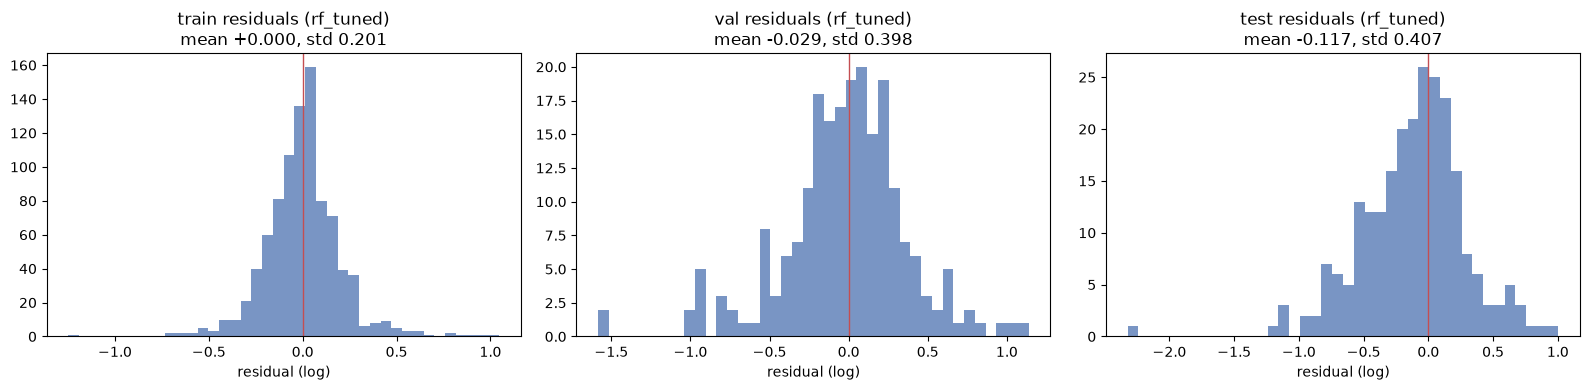

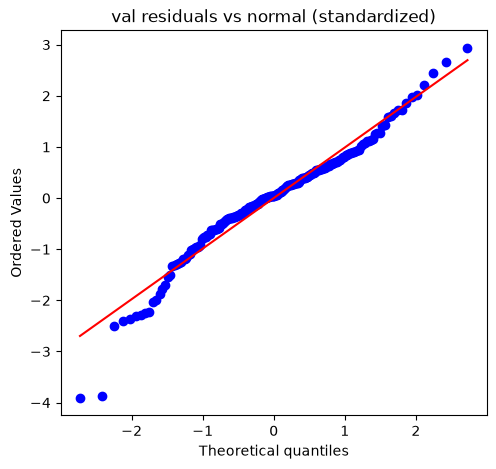

In [8]:
pred = pens["rf_tuned"].to_numpy()
resid = y - pred

dist = []
for s in ("train", "val", "test"):
    m = masks[s]
    r = resid[m]
    dist.append({"split": s, "n": int(m.sum()),
                 "mean": round(float(r.mean()), 4), "std": round(float(r.std()), 4),
                 "skew": round(float(stats.skew(r)), 3),
                 "kurt": round(float(stats.kurtosis(r)), 3),
                 "RMSE": round(rmse(y[m], pred[m]), 4),
                 "MAE": round(mae(y[m], pred[m]), 4)})
print(pd.DataFrame(dist).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, s in zip(axes, ("train", "val", "test")):
    m = masks[s]
    r = resid[m]
    ax.hist(r, bins=40, color="#4C72B0", alpha=0.75)
    ax.axvline(0, color="#C44E52", lw=1)
    ax.set_title(f"{s} residuals (rf_tuned)\nmean {r.mean():+.3f}, std {r.std():.3f}")
    ax.set_xlabel("residual (log)")
fig.tight_layout()
plt.show()

zv = (resid[masks["val"]] - resid[masks["val"]].mean()) / resid[masks["val"]].std()
fig, ax = plt.subplots(figsize=(5.5, 5))
stats.probplot(zv, dist="norm", plot=ax)
ax.set_title("val residuals vs normal (standardized)")
plt.show()

In [9]:
vt = masks["val"] | masks["test"]


def seg_table(series, title):
    series = np.asarray(series)
    rows = []
    for g in np.unique(series[vt]):
        idx = vt & (series == g)
        rows.append({"segment": g, "n": int(idx.sum()),
                     "RMSE": round(rmse(y[idx], pred[idx]), 4),
                     "MAE": round(mae(y[idx], pred[idx]), 4),
                     "bias": round(float((y[idx] - pred[idx]).mean()), 4),
                     "R2": round(r2(y[idx], pred[idx]), 3)})
    out = pd.DataFrame(rows).sort_values("n", ascending=False)
    print(f"### {title}\n")
    print(out.to_string(index=False))
    print()


pos_cols = [c for c in prep if c.startswith("pos_")]
pos_series = pd.Series(
    prep[pos_cols].idxmax(axis=1).map({c: c[4:].upper() for c in pos_cols}),
    index=prep.index).where(prep[pos_cols].any(axis=1), "n/a")

exp_b = pd.cut(prep["years_pro"], bins=[-1, 0, 3, 6, 9, np.inf],
               labels=["0 (rookie)", "1-3 (early)", "4-6 (mid)", "7-9 (prime)",
                       "10+ (vet)"]).astype(str)

mpg_v = prep["prior_mpg"].mask(prep["has_prior_stats"] == 0, np.nan)
mpg_cat = pd.cut(mpg_v, bins=[-np.inf, 10, 20, 30, np.inf],
                 labels=["<10 (deep bench)", "10-20 (rotation)",
                         "20-30 (starter)", "30+ (star)"]).astype(str)
mpg_cat = mpg_cat.mask(prep["has_prior_stats"] == 0, "no prior season (imputed)")

mech = pd.Series("other", index=prep.index)
for c, label in (("signed_via_extension", "extension"),
                 ("signed_via_free_agency", "free agency"),
                 ("signed_via_offer_sheet", "offer sheet"),
                 ("signed_via_sign_and_trade", "sign-and-trade")):
    mech = mech.where(prep[c].eq(0), label)

seg_table(pos_series, "errors by position (rf_tuned, val+test)")
seg_table(exp_b, "errors by experience bucket")
seg_table(mpg_cat, "errors by prior-season minutes")
seg_table(prep["team_market_size_ord"].astype(int), "errors by market size (0 = smallest)")
seg_table(prep["at_ceiling"].astype(int), "errors by ceiling status (1 = cap-bound)")
seg_table(prep["undrafted"].astype(int), "errors by undrafted flag")
seg_table(mech, "errors by deal mechanism")
seg_table(prep["deal_year"].astype(int), "errors by deal year (out-of-sample trend)")
cont_sign = (pd.Series(np.where(prep["team_nrtg"].ge(4.0), "contender", "non-contender"),
                       index=prep.index) + " / " +
             pd.Series(np.where(prep["incumbent"].eq(1), "re-sign", "mover"),
                       index=prep.index))
seg_table(cont_sign, "errors by contender x signing type (rf_tuned, val+test)")

### errors by position (rf_tuned, val+test)

segment   n   RMSE    MAE    bias    R2
      C 100 0.4361 0.3216 -0.1593 0.773
     SG  93 0.3882 0.2933 -0.0594 0.841
     PF  82 0.3587 0.2731 -0.1009 0.845
     SF  65 0.5055 0.3680 -0.0856 0.660
     PG  62 0.4414 0.3486 -0.1097 0.806
     NA  56 0.3152 0.1805  0.1325 0.209

### errors by experience bucket

    segment   n   RMSE    MAE    bias    R2
  4-6 (mid) 129 0.3985 0.3145 -0.1096 0.760
7-9 (prime)  96 0.4303 0.3163 -0.0715 0.754
1-3 (early)  95 0.3475 0.2643 -0.0615 0.870
  10+ (vet)  82 0.5244 0.3819 -0.1861 0.672
 0 (rookie)  56 0.3152 0.1805  0.1325 0.209

### errors by prior-season minutes

                  segment   n   RMSE    MAE    bias    R2
          20-30 (starter) 166 0.4602 0.3533 -0.1175 0.503
         10-20 (rotation) 112 0.3944 0.3205 -0.1648 0.477
               30+ (star)  96 0.4217 0.2736 -0.0012 0.507
no prior season (imputed)  61 0.3426 0.2084  0.0993 0.286
         <10 (deep bench)  23 0.2118 0.1717 -0.115

In [10]:
d = pd.DataFrame({"player": prep["player_name"], "split": prep["split"],
                  "year": prep["deal_year"], "actual": y, "pred": pred, "resid": resid,
                  "actual_share": prep["aav"], "pred_share": np.exp(pred)})
d = d.loc[vt].sort_values("resid")


def show(df, title):
    print(title)
    print(df[["player", "split", "year", "actual", "pred", "resid",
              "actual_share", "pred_share"]].round(3).to_string(index=False))
    print()


show(d.head(10), "TOP 10 UNDERPAID — model predicts below actual (val+test)")
show(d.sort_values("resid", ascending=False).head(10),
     "TOP 10 OVERPAID — model predicts above actual (val+test)")

TOP 10 UNDERPAID — model predicts below actual (val+test)
           player split  year  actual   pred  resid  actual_share  pred_share
     LeBron James  test  2026  -3.758 -1.435 -2.323         0.023       0.238
   Christian Wood   val  2023  -3.857 -2.272 -1.585         0.021       0.103
 Montrezl Harrell   val  2022  -3.858 -2.292 -1.567         0.021       0.101
   Damian Lillard  test  2025  -2.402 -1.208 -1.194         0.091       0.299
     Bradley Beal  test  2025  -3.338 -2.232 -1.106         0.036       0.107
       Saddiq Bey  test  2024  -3.100 -1.994 -1.106         0.045       0.136
       Gui Santos  test  2026  -3.622 -2.531 -1.091         0.027       0.080
     Torrey Craig   val  2023  -3.925 -2.899 -1.026         0.020       0.055
Russell Westbrook   val  2023  -3.544 -2.562 -0.982         0.029       0.077
De'Anthony Melton  test  2025  -3.858 -2.889 -0.969         0.021       0.056

TOP 10 OVERPAID — model predicts above actual (val+test)
         player split  yea

## 6. The context questions — market size and the contender discount

Two environment questions, answered as standardized coefficient paths across the
linear, ceiling-aware, and tree models.

**Q1 — market size.** Does a big market pay more?

1. **Linear chosen model** (MODEL 02 §7): L1 regularization shrinks all five
   market features to exactly 0 — no market premium in the chosen model.
2. **OLS / Tobit-latent** (MODEL 04): individual coefficients range from
   −0.11 to +0.07 due to multicollinearity among the five correlated market
   features, but the net effect is approximately zero; de-censoring does
   not resurrect a market premium.
3. **Best tree model** (MODEL 03 §7): flat partial dependence on
   `team_market_size_ord`.

**Q2 — the contender discount.** Do players take below-market money to join a
good team, and does it differ by signing type?

1. **Linear chosen model** (MODEL 02 §7): `team_nrtg` coefficient ≈ −0.07 —
   better teams pay less.
2. **OLS / Tobit-latent** (MODEL 04): −0.12 to −0.13 — the
   discount survives de-censoring.
3. **Mechanism** (MODEL 02 §7b): the re-sign vs mover interaction is exactly 0
   (no difference by signing type); the star interaction is ≈ −0.03 (stars take
   a bigger discount).
4. **Magnitude** (MODEL 02 §7c): a `contender` signing (`team_nrtg >= +4.0`) is
   worth ≈ +0.03 to +0.06 log less than a talent-only price (~0.4% of cap) —
   real but modest; mover × contender cells are small (n ≈ 21 pooled), so treat
   the split as descriptive.

Consistent answer: pay tracks player quality; market size adds nothing, and team
quality subtracts a little.

In [11]:
mc = pd.DataFrame(ceiling["market_coefficients"]).T.rename(
    columns={"ols": "OLS linear", "tobit_latent": "Tobit latent"})
print("market-size standardized coefficients (log target, standardized features):")
print(mc.round(4).to_string())
print("\nmax |coefficient| across both models:", round(float(mc.abs().to_numpy().max()), 4))

tq = pd.DataFrame(ceiling["team_quality_coefficients"]).T.rename(
    columns={"ols": "OLS linear", "tobit_latent": "Tobit latent"})
print("\nteam-quality standardized coefficients (log target, standardized features):")
print(tq.round(4).to_string())
print("\nreading: negative across both -> good teams pay less; the discount")
print("survives de-censoring and is larger than the shrunken ElasticNet read.")

print("\nper-deal team-quality discount, by contender x signing type (MODEL 02 §7c):")
for label, (sub, grp) in (("val", ("val", "all")),
                          ("val+test", ("val_test", "all")),
                          ("val+test, stars only", ("val_test", "star"))):
    df = pd.DataFrame(contender["below_market_discount"][sub][grp])
    df["disc_$M"] = (df["disc_cap_share"] * 140).round(2)   # approx, $140M cap
    print(f"\n### {label}")
    print(df.to_string(index=False))
print("\nCorroboration (MODEL 03 §7): flat partial dependence on team_market_size_ord")
print("(markets do not pay more) and a downward-sloping team_nrtg dependence (good")
print("teams pay less) hold in the best tree model too.")

market-size standardized coefficients (log target, standardized features):
                      OLS linear  Tobit latent
team_market_size_ord     -0.1089       -0.1067
team_big_market           0.0742        0.0735
team_metro_pop_m         -0.0746       -0.0746
team_dma_rank            -0.0633       -0.0618

max |coefficient| across both models: 0.1089

team-quality standardized coefficients (log target, standardized features):
                    OLS linear  Tobit latent
team_nrtg              -0.1246       -0.1225
team_made_playoffs      0.0153        0.0137

reading: negative across both -> good teams pay less; the discount
survives de-censoring and is larger than the shrunken ElasticNet read.

per-deal team-quality discount, by contender x signing type (MODEL 02 §7c):

### val
                segment   n  disc_log  disc_cap_share  disc_$M
   contender=no / mover  52       0.0             0.0      0.0
 contender=no / re-sign 128       0.0             0.0      0.0
  contender=yes / 

## 7. Limitations & threats to validity

- **Censoring is thin and the Heckman was declined.** A relative 3% band
  identifies 22 deals at/near their AAV ceiling (15 in train), all legitimate
  max-contract stars. The Tobit MLE is registered; a two-stage Heckman was
  declined — the Probit is near-separated (15 censored rows vs 59+1
  regressors), the Hessian does not invert, so no ρσ / p-value is reported,
  and no clean exclusion restriction exists.
- **Quantile tails.** The linear quantile function captures the bulk but not the
  cap's nonlinear binding at the top; coverage falls to 75.1% on test.
- **Test set is small** (n=181) and late (2024-25); the 2023 CBA regime is only
  observed there.
- **No agent/leverage data** — negotiating power, injuries, and fit are proxied
  only by statistics.
- **Selection on unobservables** — *who* signs an extension vs free agency is a
  choice the model takes as given.
- **Ensemble overfit on train** (train RMSE ≈ 0.16-0.20); val/test gaps are the
  honest numbers.
- **Position is missing for ~19% of deals** (bucketed `n/a`); results are robust
  to the flag, but the flag itself is coarse.

## 8. Conclusions & recommendation

**Recommendation: deploy `linear_interpretable` for stakeholder-facing use and
`rf_tuned` where accuracy matters more than explanation.**

- `linear_interpretable` (val log-RMSE 0.470, R² 0.791) has a small, documented
  feature list and stable, readable coefficients — the defensible default for a
  "why this price?" question.
- `rf_tuned` (val log-RMSE 0.399, R² 0.849; test 0.424) is the accuracy winner;
  permutation importances and partial-dependence plots cover the transparency
  gap for the headline drivers.

- **The contender discount is real but modest.** Controlling for player quality,
  better signing teams pay less (`team_nrtg` ≈ −0.07 ElasticNet; −0.12 to −0.13
  OLS/Tobit); stars give up a bit more and re-signings vs movers do not
  differ. It is a general "good team pays less" effect — ~0.4% of cap — small
  next to the quality-driven spread in pay.

**What the market taught us.** (1) Pay tracks *total* on-court production — the
advanced composites (PER/BPM/VORP/WS) dominate; raw skill mix and position×stat
interactions add nothing. (2) Experience and minutes still matter after
controlling for production. (3) Market size does not drive pay once quality is
controlled. (4) The cap ceiling binds on very few deals; correcting for it does
not change the qualitative conclusions. (5) Uncertainty is wide at the top of
the market, and well-calibrated intervals must be wide there — any single-number
forecast of a max deal should be reported with its [q10, q90].

## 9. Reproducibility

Artifacts, pipeline order, and execution commands. Every figure in this report is
regenerable by re-running `MODEL_01..04` then this notebook; nothing is hardcoded
outside the executables. `data/model/contender_metrics.json` (the Q2 coefficient
paths and per-deal discount tables) is written by `MODEL_02` and read here.

In [12]:
print("artifacts (data/model/):")
for f in sorted(DM.iterdir()):
    print(f"{f.name:35s} {f.stat().st_size:>10,} bytes")
print()
print("pipeline:")
print("  consolidation/build_dataset.py  -> features.csv")
print("  notebooks/PREP.ipynb            -> prep.csv, prep_columns.json")
print("  notebooks/MODEL_01..04          -> results.csv, predictions_*, *_metrics.json")
print("  notebooks/REPORT.ipynb          -> this report")
print("shared metrics: notebooks/metrics.py (rmse/mae/r2/evaluate)")
print("execution (cwd = notebooks/):")
print("  ../.venv/bin/jupyter nbconvert --to notebook --execute --inplace <NB>.ipynb")

artifacts (data/model/):
ceiling_metrics.json                     1,070 bytes
contender_metrics.json                   5,157 bytes
features.csv                           555,065 bytes
features.md                              6,983 bytes
interval_metrics.json                      892 bytes
linear_features.json                     4,839 bytes
predictions_baselines.csv               97,408 bytes
predictions_ensemble.csv               159,042 bytes
predictions_linear.csv                 160,206 bytes
predictions_quantile.csv               133,427 bytes
prep.csv                               508,199 bytes
prep_columns.json                        4,616 bytes
results.csv                              7,469 bytes

pipeline:
  consolidation/build_dataset.py  -> features.csv
  notebooks/PREP.ipynb            -> prep.csv, prep_columns.json
  notebooks/MODEL_01..04          -> results.csv, predictions_*, *_metrics.json
  notebooks/REPORT.ipynb          -> this report
shared metrics: notebooks/metri